### BASIC TEXT CLEANING

In [ ]:
import pandas as pd
import re

print("IMPORTING LIBRARIES AND LOADING DATA")

# Setting pandas display options for better visibility in Jupyter Notebook
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Loading data that should already be downloaded from Kaggle
df = pd.read_csv("../data/raw/realdonaldtrump.csv")
print(df.shape)
df.head()

# Defining a robust text cleaning function
def clean_tweet(text: str) -> str:
    """
    Cleans the input tweet text by:
    - Lowercasing
    - Removing URLs
    - Removing user mentions
    - Removing special characters and emojis
    - Normalizing whitespace
    """
    # Handle any missing values by returning an empty string
    if not isinstance(text, str):
        return ""

    # Lowercase the text
    text = text.lower()


    # Remove URLs:
    # - http...
    # - https...
    # - www...
    # - pic.twitter.com/... without http/www
    text = re.sub(r'http\S+|www\.\S+|pic\.twitter\.com/\S+', ' ', text)

    # Clean user mentions (e.g., @realdonaldtrump)
    text = re.sub(r'@', '', text)

    # Remove special characters, and emojis
    # (Keeps only standard English alphabetical characters, numbers and spaces)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Remove extra whitespaces that might have appeared after removing words
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("TEXT CLEANING IN PROGRESS")

# Apply the function to create a NEW column
# We keep the original 'content' column safe
df['cleaned_content'] = df['content'].apply(clean_tweet)

# Display the results to compare original text with the cleaned version
print("Original vs Cleaned Tweets (First 5 rows):")
# Use pandas display functionality to show it nicely in Jupyter
display(df[['content', 'cleaned_content']].head())

IMPORTING LIBRARIES AND LOADING DATA
(43352, 8)
TEXT CLEANING IN PROGRESS
Original vs Cleaned Tweets (First 5 rows):


,content,cleaned_content
0,Be sure to tune in and watch Donald Trump on Late Night with David Letterman as he presents the Top Ten List tonight!,be sure to tune in and watch donald trump on late night with david letterman as he presents the top ten list tonight
1,Donald Trump will be appearing on The View tomorrow morning to discuss Celebrity Apprentice and his new book Think Like A Champion!,donald trump will be appearing on the view tomorrow morning to discuss celebrity apprentice and his new book think like a champion
2,Donald Trump reads Top Ten Financial Tips on Late Show with David Letterman: http://tinyurl.com/ooafwn - Very funny!,donald trump reads top ten financial tips on late show with david letterman very funny
3,New Blog Post: Celebrity Apprentice Finale and Lessons Learned Along the Way: http://tinyurl.com/qlux5e,new blog post celebrity apprentice finale and lessons learned along the way
4,"""My persona will never be that of a wallflower - I’d rather build walls than cling to them"" --Donald J. Trump",my persona will never be that of a wallflower i d rather build walls than cling to them donald j trump


### LINGUISTIC TEXT CLEANING

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK datasets
# 'punkt' is for tokenization, 'wordnet' for lemmatization
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize the tools
base_stop_words = set(stopwords.words('english'))
words_to_keep = {
    "i", "me", "my", "mine",
    "you", "your", "yours",
    "we", "us", "our", "ours",
    "he", "him", "his",
    "she", "her", "hers",
    "they", "them", "their", "theirs",
    "no", "not", "nor", "never",
    "will", "would", "can", "could", "must", "should"
}
custom_stop_words = base_stop_words - words_to_keep
lemmatizer = WordNetLemmatizer()

# Define the NLP processing function
def process_nlp(text: str) -> str:
    """
    Processes the input text by tokenizing, removing stopwords, lemmatizing, and rejoining into a cleaned string.
    """
    # Fallback for empty values
    if not text or not isinstance(text, str):
        return ""

    # A. Tokenization: Split text into a list of individual words
    tokens = word_tokenize(text)

    # B. Stopwords removal and 
    # C. Lemmatization
    # We also remove words that are just 1 character long (e.g., isolated 's' or 't') but keep 'i' as it's a common pronoun
    processed_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in custom_stop_words and (len(word) > 1 or word == "i")
    ]

    # D. Rejoin into a single string
    # (Models like TF-IDF (Term Frequency-Inverse Document Frequency) require string format, not lists)
    return " ".join(processed_tokens)

print("NLP PROCESSING IN PROGRESS")

# Apply the function to create the final processed column
df['processed_content'] = df['cleaned_content'].apply(process_nlp)

# We preserve the original 'hashtags' and 'mentions' columns from the Kaggle dataset
# and convert them to binary flags (0/1). These serve as an independent signal
# from the structural counts derived from raw text in notebook 03.
df['has_hashtag'] = df['hashtags'].notna().astype(int)
df['has_mention'] = df['mentions'].notna().astype(int)

# Display the full transformation pipeline
print("\nPipeline Check (Original -> Cleaned -> Processed):")
display(df[['content', 'cleaned_content', 'processed_content']].head())

[nltk_data] Downloading package punkt to /home/patryk/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/patryk/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /home/patryk/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/patryk/nltk_data...


NLP PROCESSING IN PROGRESS

Pipeline Check (Original -> Cleaned -> Processed):


,content,cleaned_content,processed_content
0,Be sure to tune in and watch Donald Trump on Late Night with David Letterman as he presents the Top Ten List tonight!,be sure to tune in and watch donald trump on late night with david letterman as he presents the top ten list tonight,sure tune watch donald trump late night david letterman he present top ten list tonight
1,Donald Trump will be appearing on The View tomorrow morning to discuss Celebrity Apprentice and his new book Think Like A Champion!,donald trump will be appearing on the view tomorrow morning to discuss celebrity apprentice and his new book think like a champion,donald trump will appearing view tomorrow morning discus celebrity apprentice his new book think like champion
2,Donald Trump reads Top Ten Financial Tips on Late Show with David Letterman: http://tinyurl.com/ooafwn - Very funny!,donald trump reads top ten financial tips on late show with david letterman very funny,donald trump read top ten financial tip late show david letterman funny
3,New Blog Post: Celebrity Apprentice Finale and Lessons Learned Along the Way: http://tinyurl.com/qlux5e,new blog post celebrity apprentice finale and lessons learned along the way,new blog post celebrity apprentice finale lesson learned along way
4,"""My persona will never be that of a wallflower - I’d rather build walls than cling to them"" --Donald J. Trump",my persona will never be that of a wallflower i d rather build walls than cling to them donald j trump,my persona will never wallflower i rather build wall cling them donald trump


### ADDING BONUS FEATURES AND EXPORTING CLEANED DATASET

In [ ]:
import os

# Calculate the 33rd and 67th percentiles for 'retweets'
p33 = df['retweets'].quantile(0.3333)
p67 = df['retweets'].quantile(0.6667)

# Create a new column 'engagement_level' based on these thresholds
def categorize_engagement(retweets: int) -> str:
    """
    Categorizes engagement level based on retweet counts.
    """
    if retweets <= p33:
        return 'Low'
    elif retweets <= p67:
        return 'Medium'
    else:
        return 'High'

df['engagement_level'] = df['retweets'].apply(categorize_engagement)

# Add the tweet length based on the original 'content' column
df['tweet_length'] = df['content'].astype(str).apply(len)

# Define the directory and filename
output_dir = '../data/processed'
output_filename = 'cleaned_realdonaldtrump.csv'

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directory created: {output_dir}")

# Save the dataframe to the specified path
full_path = os.path.join(output_dir, output_filename)
df.to_csv(full_path, index=False)

# Confirm the file was saved and check its size
file_size_mb = os.path.getsize(full_path) / (1024 * 1024)
print(f"Success! Dataset saved at: {full_path}")
print(f"File size: {file_size_mb:.2f} MB")
print("Engagement labels and binary metadata flags added successfully!")

Success! Dataset saved at: ../data/processed/cleaned_realdonaldtrump.csv
File size: 19.59 MB
Engagement labels and binary metadata flags added successfully!


### GENERATING WORDCLOUD

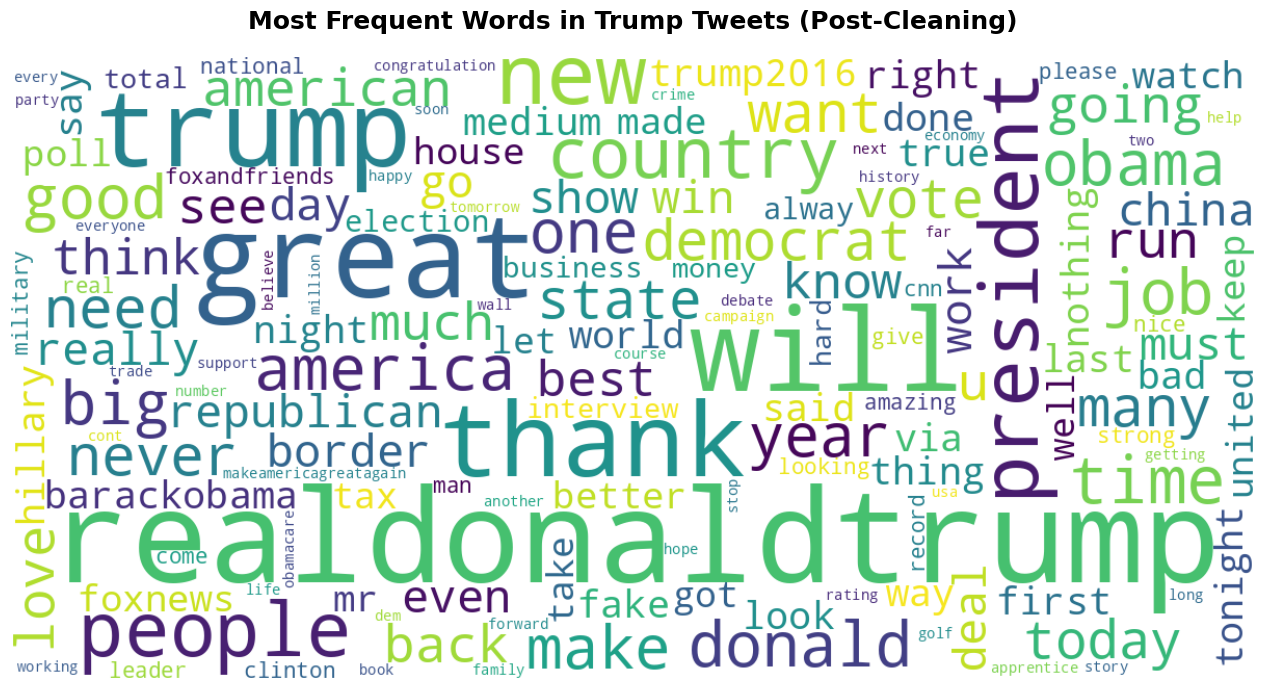

In [7]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine all processed tweets into one massive string
# We use 'processed_content' because it is already free of stopwords, links, and punctuation
all_words = ' '.join(text for text in df['processed_content'] if isinstance(text, str))

# Configure and generate the WordCloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',  # 'viridis' or 'plasma'
    max_words=150,       # Display the top 150 most frequent words
    collocations=False   # Avoids duplicating word pairs like "fake news" if they appear often
).generate(all_words)

# Plot the WordCloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axes for a cleaner look
plt.title('Most Frequent Words in Trump Tweets (Post-Cleaning)', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [8]:
from collections import Counter

# Combine all processed tweets into a list of words
# We skip empty strings to be clean
all_words = ' '.join(df['processed_content'].fillna("").astype(str)).split()

# Count the frequencies
word_counts = Counter(all_words)

# Get the top 20 most frequent words
top_20 = word_counts.most_common(20)

print("TOP 20 MOST FREQUENT WORDS")
for word, count in top_20:
    print(f"{word}: {count}")

TOP 20 MOST FREQUENT WORDS
i: 10800
you: 10718
realdonaldtrump: 8639
great: 6767
will: 6678
trump: 5700
we: 5035
our: 4597
he: 4451
they: 3848
my: 3838
not: 3654
thank: 3060
president: 3034
people: 2727
your: 2685
can: 2624
no: 2384
thanks: 2334
country: 2314
